In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data_path = "/feynman/work/dap/lcs/vt272285/final_codes/WALE/data/filtertophat_results_15_tomobin5_simulationTrue.npy"

data = np.load(data_path, allow_pickle=True).item()
# Extracting the data

Om_array = []
sig8_array = []
h_array = []
w_array = []
sigma_sq_array = []
l1_array = []
snr_array = []
l1_sim_array = []

# Define common kappa grid
edges = np.linspace(-0.04, 0.04, 801)
centers = 0.5 * (edges[:-1] + edges[1:])

kappas_vals = centers
kappas = []
sim_sigmas = []
for idx, entry in data.items():
    cosmo = entry['cosmology']
    sigma_sq = entry['perturbation_theory_sigma_sq']  # float or scalar
    sim_sigma = entry['simvar']          # float or scalar
    l1s = np.asarray(entry['prediction_l1'])          # shape: (M,)
    snrs = np.asarray(entry['snr'])                   # shape: (M,)
    om = cosmo['Om']
    sig8 = cosmo['sigma8']
    h = cosmo['h']
    w = cosmo['w']
    
    l1_sim = entry['sim_l1_runs']  # shape: (M,n)
    # Ensure shapes: snrs = (800, 1), sqrt_sigma = (1, 10)
    kappa = snrs[:, None] * np.sqrt(sim_sigma)[None, :]

    kappas.append(kappa)
    sigma_sq_array.append(sigma_sq)
    sim_sigmas.append(sim_sigma)
    l1_array.append(l1s)
    l1_sim_array.append(l1_sim)
    snr_array.append(snrs)
    Om_array.append(om)
    sig8_array.append(sig8)
    h_array.append(h)
    w_array.append(w)

Om_array = np.array(Om_array)
sig8_array = np.array(sig8_array)
h_array = np.array(h_array)
w_array = np.array(w_array)
sigma_sq_array = np.array(sigma_sq_array)
l1_array = np.array(l1_array)
l1_sim_array = np.array(l1_sim_array)
snr_array = np.array(snr_array)
kappas = np.array(kappas)
# Transpose last two axes: (n_cosmo, n_bins, n_sim) → (n_cosmo, n_sim, n_bins)
kappas = kappas.transpose(0, 2, 1)

sim_sigmas = np.array(sim_sigmas)


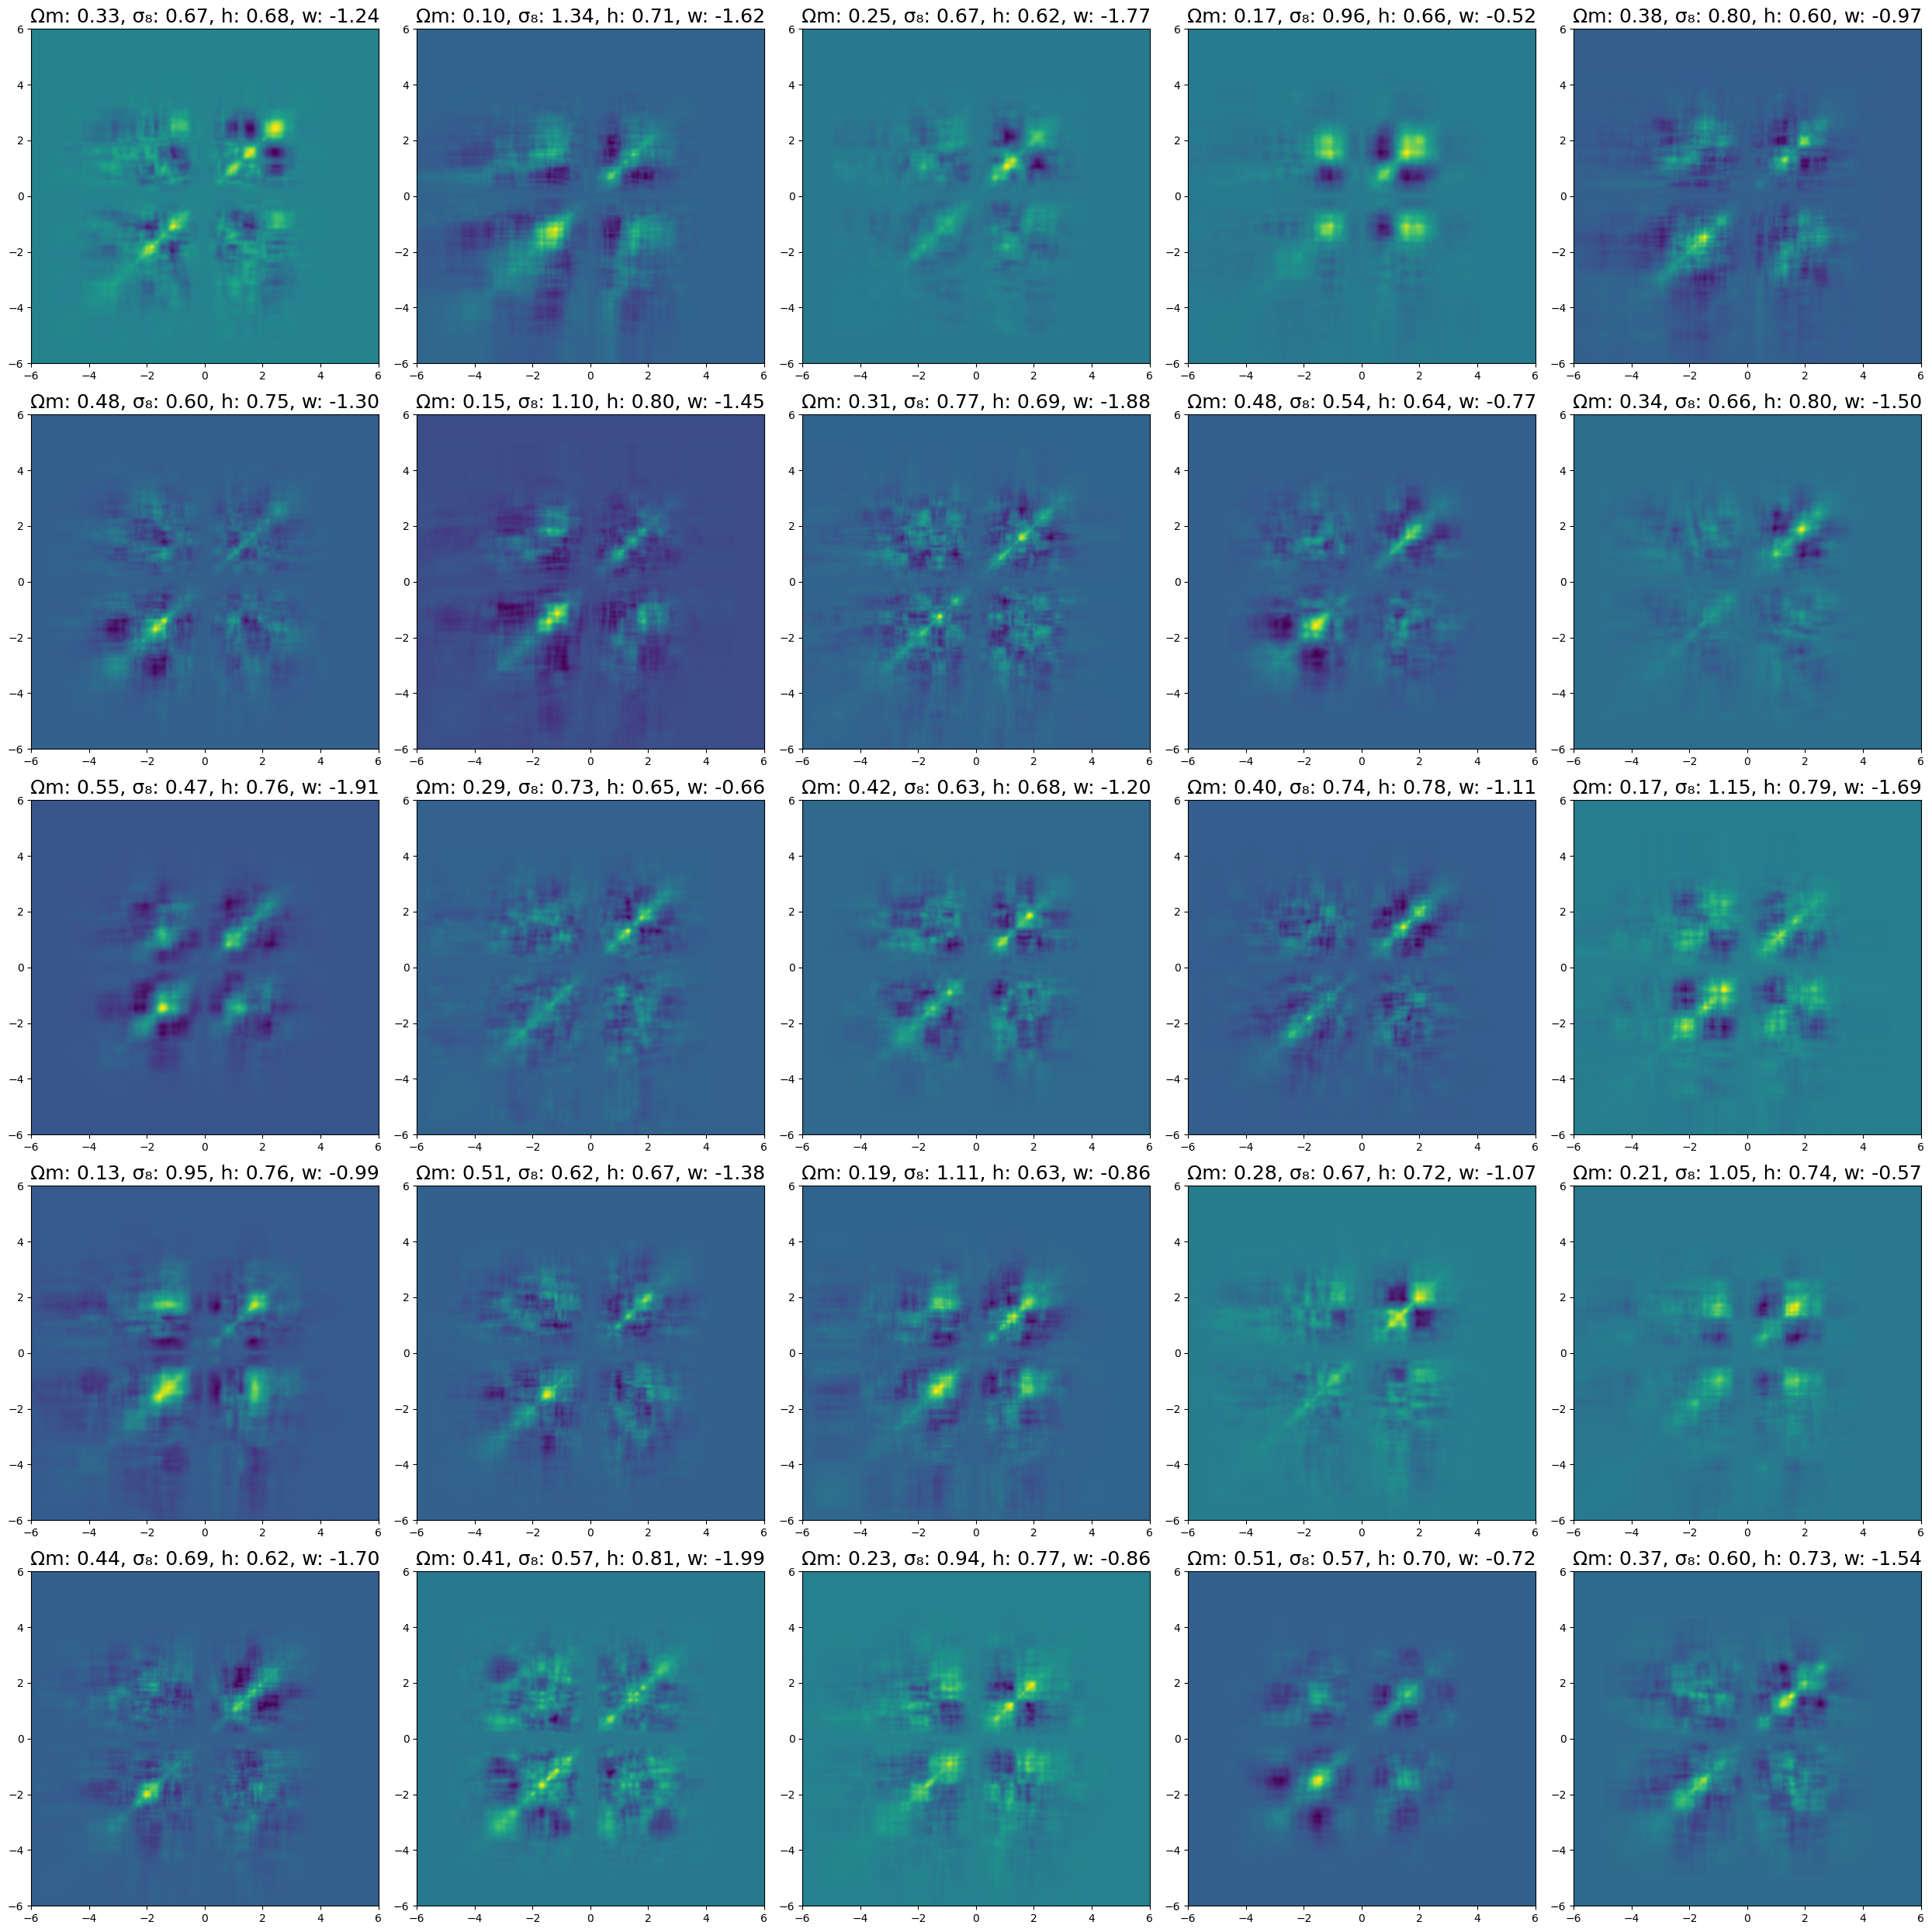

In [3]:
l1_sim_array.shape
n_cosmo, n_sim, n_bins = l1_sim_array.shape

fig, axs = plt.subplots(5, 5, figsize=(25, 25))
covariances = []
for i in range(5):
    for j in range(5):
        ax = axs[i, j]
        idx = i * 5 + j
        if idx < n_cosmo:
            cov = np.cov(l1_sim_array[idx], rowvar=False)  
            covariances.append(cov)
            im = ax.imshow(
                cov, cmap='viridis', aspect='auto', origin='lower',
                extent=[snr_array[0][0], snr_array[0][-1], snr_array[0][0], snr_array[0][-1]]
            )
            ax.set_title(
                f"Ωm: {Om_array[idx]:.2f}, σ₈: {sig8_array[idx]:.2f}, h: {h_array[idx]:.2f}, w: {w_array[idx]:.2f}",
                fontsize=18
            )
        else:
            ax.axis('off')

plt.tight_layout()
plt.show()


/feynman/home/dap/lcs/vt272285/.conda/envs/general/lib/python3.8/site-packages/sklearn/gaussian_process/kernels.py:419: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-10. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


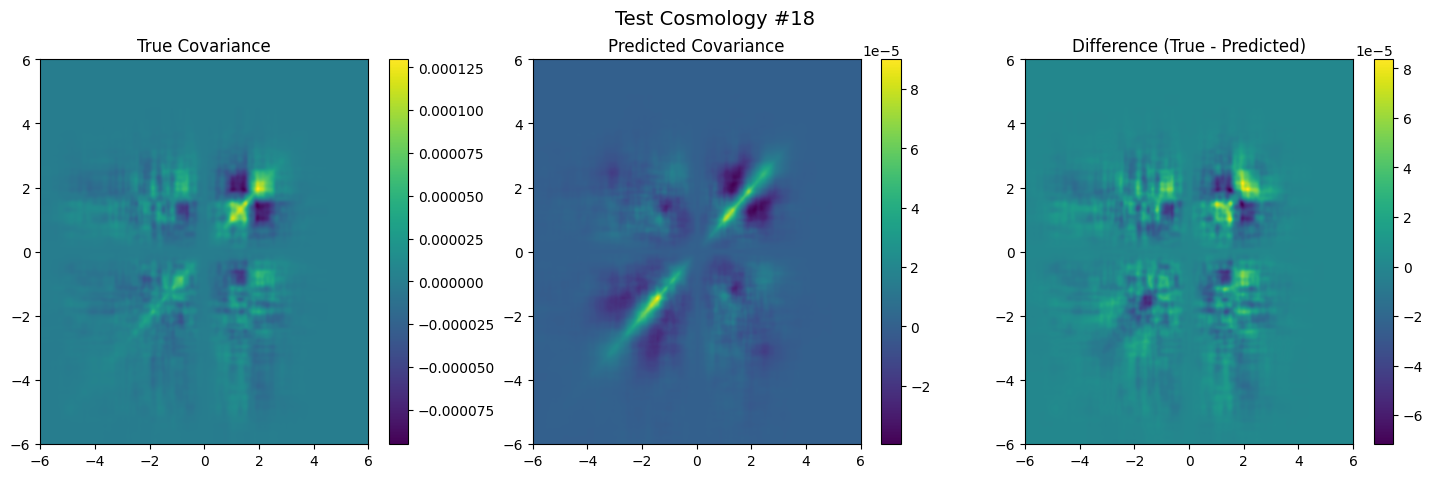

Explained variance ratio: [0.40440655 0.095855   0.08280299]
Total explained variance: 0.5831


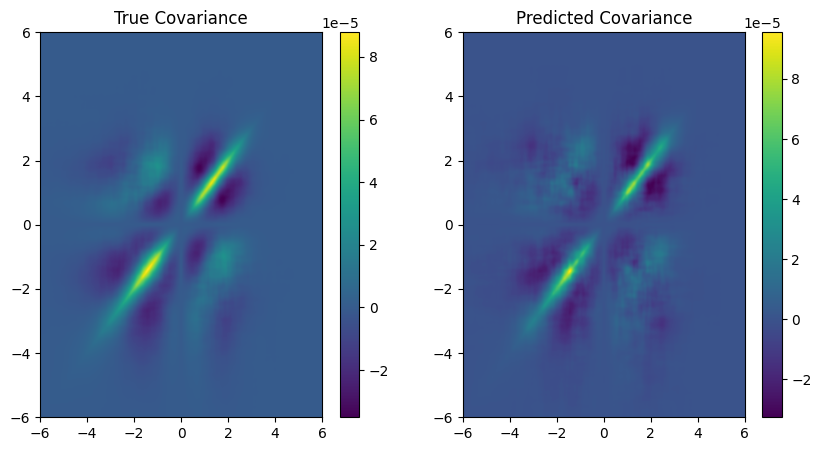

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
from sklearn.decomposition import PCA

from sklearn.preprocessing import StandardScaler

# Stack cosmological params
X_cosmo = np.stack([Om_array, sig8_array, h_array, w_array], axis=1)  # shape: (25, 4)

def vectorize_cov(C):
    return C[np.triu_indices_from(C)]

# Vectorized covariances
cov_vecs = np.array([vectorize_cov(np.cov(l1_sim_array[i], rowvar=False)) for i in range(n_cosmo)])

# Train/test split
X_train, X_test, Y_train, Y_test, idx_train, idx_test = train_test_split(
    X_cosmo, cov_vecs, np.arange(n_cosmo), test_size=1
)

n_components = 3
pca_cov = PCA(n_components=n_components)
Y_train_pca = pca_cov.fit_transform(Y_train)

scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

from sklearn.gaussian_process.kernels import RBF, Matern, WhiteKernel, ConstantKernel as C


# Fit GP on scaled features
gp_cov_models = []
for i in range(n_components):
    gp = GaussianProcessRegressor(
        kernel=RBF(length_scale=1.0, length_scale_bounds=(1e-10, 1e5)), 
        alpha=1e-4, 
        normalize_y=True,
        n_restarts_optimizer=10
    )
    # gp = GaussianProcessRegressor(
    #     kernel=C(1.0, (1e-3, 1e3)) * RBF(length_scale=[1.0]*4, length_scale_bounds=(1e-3, 1e6)) \
    #      + WhiteKernel(noise_level=1e-5, noise_level_bounds=(1e-10, 1e2)), 
    #     alpha=1e-3, 
    #     normalize_y=True,
    #     n_restarts_optimizer=10
    # )
    gp.fit(X_train_scaled, Y_train_pca[:, i])
    gp_cov_models.append(gp)

# Modify predict_covariance accordingly:
def predict_covariance(cosmo_vector):
    cosmo_vector_scaled = scaler_X.transform(cosmo_vector.reshape(1, -1))
    pred_pca = np.array([
        gp.predict(cosmo_vector_scaled)[0] for gp in gp_cov_models
    ])
    pred_cov_vec = pca_cov.inverse_transform(pred_pca)

    n_elements = len(pred_cov_vec)
    n_bins = int((-1 + np.sqrt(1 + 8 * n_elements)) // 2)
    cov_recon = np.zeros((n_bins, n_bins))
    idx = np.triu_indices(n_bins)
    cov_recon[idx] = pred_cov_vec
    cov_recon[(idx[1], idx[0])] = pred_cov_vec
    cov_recon = 0.5 * (cov_recon + cov_recon.T)
    return cov_recon


for i, test_idx in enumerate(idx_test):
    pred_cov = predict_covariance(X_cosmo[test_idx])
    true_cov = np.cov(l1_sim_array[test_idx], rowvar=False)

    plt.figure(figsize=(18, 5))
    plt.suptitle(f"Test Cosmology #{test_idx}", fontsize=14)

    plt.subplot(1, 3, 1)
    plt.imshow(true_cov, cmap='viridis', aspect='auto', origin='lower',
                extent=[snr_array[0][0], snr_array[0][-1], snr_array[0][0], snr_array[0][-1]])
    plt.title("True Covariance")
    plt.colorbar()

    plt.subplot(1, 3, 2)
    plt.imshow(pred_cov, cmap='viridis', aspect='auto', origin='lower',
                extent=[snr_array[0][0], snr_array[0][-1], snr_array[0][0], snr_array[0][-1]])
    plt.title("Predicted Covariance")
    plt.colorbar()
    
    plt.subplot(1, 3, 3)
    plt.imshow(true_cov - pred_cov, cmap='viridis', aspect='auto', origin='lower',
                extent=[snr_array[0][0], snr_array[0][-1], snr_array[0][0], snr_array[0][-1]])
    plt.title("Difference (True - Predicted)")
    plt.colorbar()

    plt.show()

print(f"Explained variance ratio: {pca_cov.explained_variance_ratio_}")
print(f"Total explained variance: {np.sum(pca_cov.explained_variance_ratio_):.4f}")

Om_fid = 0.2905
sig8_fid = 0.8364
h_fid = 0.6898
w_fid = -1.0
cosmo_fid = np.array([Om_fid, sig8_fid, h_fid, w_fid])

# ---------------- Predict with your model ----------------
pred_cov_fid = predict_covariance(cosmo_fid)  # uses your scaler_X, pca_cov, gp_cov_models

# ---------------- Load "true" covariance ----------------
true_cov_fid = np.load("/feynman/work/dap/lcs/vt272285/inference/extrabins/cov_matrix_full_theta15.0_bin5.npy")

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title("True Covariance")
plt.imshow(true_cov_fid, cmap='viridis', aspect='auto', origin='lower',
                extent=[snr_array[0][0], snr_array[0][-1], snr_array[0][0], snr_array[0][-1]])
plt.colorbar()
plt.subplot(1,2,2)
plt.title("Predicted Covariance")
plt.imshow(pred_cov_fid, cmap='viridis', aspect='auto', origin='lower',
                extent=[snr_array[0][0], snr_array[0][-1], snr_array[0][0], snr_array[0][-1]])
plt.colorbar()
# plt.subplot(1,3,3)
# plt.title("Difference (True - Predicted)")
# plt.imshow(true_cov_fid - pred_cov_fid*1.2, cmap='viridis', aspect='auto', origin='lower',
#                 extent=[snr_array[0][0], snr_array[0][-1], snr_array[0][0], snr_array[0][-1]])
# plt.colorbar()


In [22]:
n_outputs = cov_vecs.shape[1]  # number of unique covariance elements
y_target = cov_vecs

X_train, X_test, y_train, y_test = train_test_split(X_cosmo, y_target, test_size=1, random_state=42)

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

model = Sequential([
    Dense(128, activation='relu', input_shape=(4,)),
    Dropout(0.1),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(n_outputs, activation='linear')
])

model.compile(optimizer=Adam(learning_rate=1e-3), loss='mse', metrics=['mae'])
model.fit(X_train_scaled, y_train, validation_data=(X_test_scaled, y_test), epochs=200, batch_size=8, verbose=1)


Epoch 1/2000
3/3 [==============================] - 1s 206ms/step - loss: 7.7147e-06 - mae: 0.0021 - val_loss: 6.8109e-06 - val_mae: 0.0021
Epoch 2/2000
3/3 [==============================] - 0s 144ms/step - loss: 6.7334e-06 - mae: 0.0019 - val_loss: 5.7413e-06 - val_mae: 0.0019
Epoch 3/2000
3/3 [==============================] - 0s 142ms/step - loss: 5.3781e-06 - mae: 0.0017 - val_loss: 4.6901e-06 - val_mae: 0.0017
Epoch 4/2000
3/3 [==============================] - 0s 145ms/step - loss: 4.2925e-06 - mae: 0.0016 - val_loss: 3.7989e-06 - val_mae: 0.0016
Epoch 5/2000
3/3 [==============================] - 0s 137ms/step - loss: 3.4644e-06 - mae: 0.0014 - val_loss: 3.0517e-06 - val_mae: 0.0014
Epoch 6/2000
3/3 [==============================] - 0s 134ms/step - loss: 2.5233e-06 - mae: 0.0012 - val_loss: 2.4422e-06 - val_mae: 0.0013
Epoch 7/2000
3/3 [==============================] - 0s 144ms/step - loss: 2.0633e-06 - mae: 0.0011 - val_loss: 1.9702e-06 - val_mae: 0.0011
Epoch 8/2000
3/3 [==

1/1 [==============================] - 0s 59ms/step


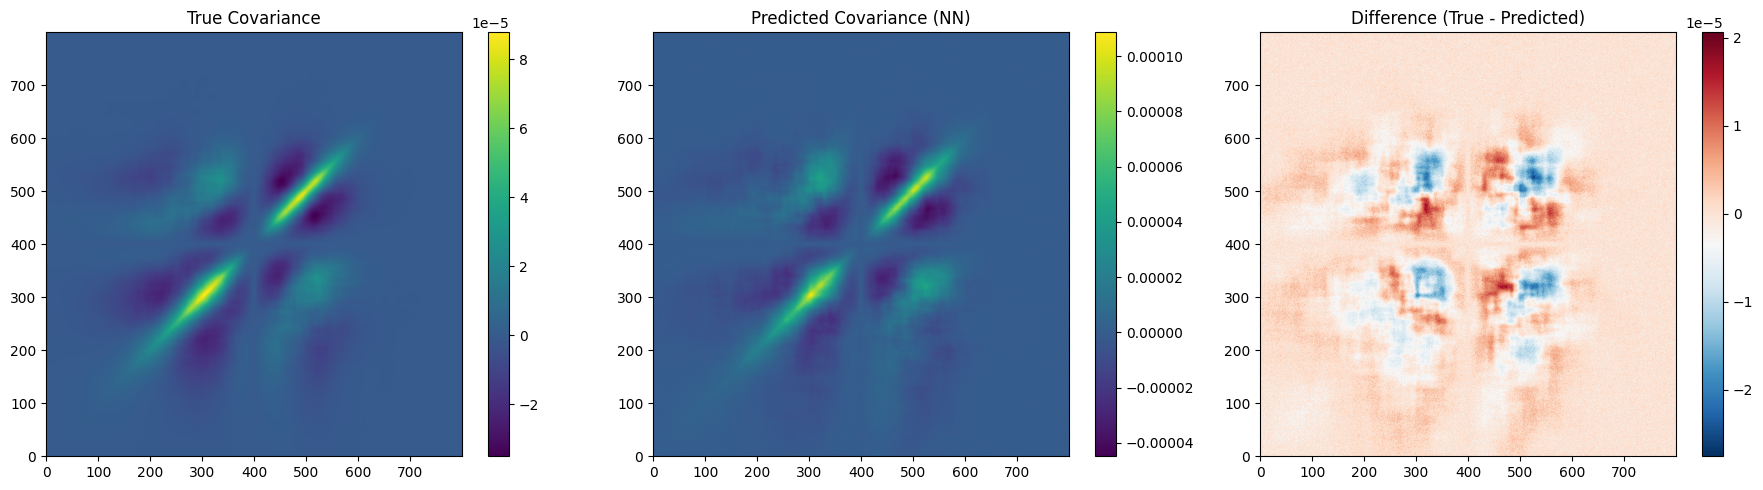

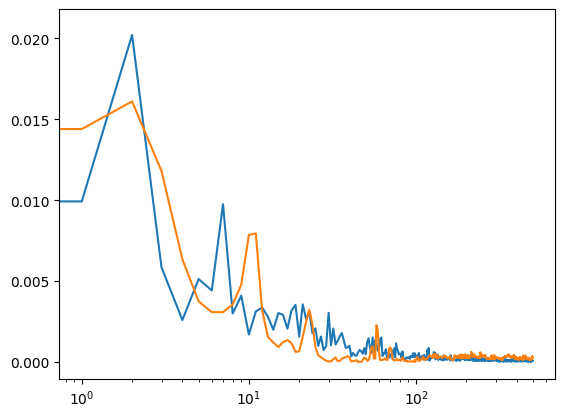

In [21]:
# --- 1. Fiducial cosmological parameters ---
Om_fid = 0.2905
sig8_fid = 0.8364
h_fid = 0.6898
w_fid = -1.0
cosmo_fid = np.array([Om_fid, sig8_fid, h_fid, w_fid])

# --- 2. Scale using your previously fitted scaler ---
cosmo_fid_scaled = scaler_X.transform(cosmo_fid.reshape(1, -1))

# --- 3. Predict vectorized covariance using your neural net ---
vec_pred = model.predict(cosmo_fid_scaled)[0]   # shape (N_vec,)

# --- 4. Reconstruct full symmetric covariance matrix ---
def reconstruct_cov(vec):
    n = int((-1 + np.sqrt(1 + 8 * len(vec))) // 2)
    C = np.zeros((n, n))
    idx = np.triu_indices(n)
    C[idx] = vec
    C[(idx[1], idx[0])] = vec
    return 0.5 * (C + C.T)

pred_cov_fid = reconstruct_cov(vec_pred)

# --- 5. Load true covariance from simulation ---
true_cov_fid = np.load("/feynman/work/dap/lcs/vt272285/inference/extrabins/cov_matrix_full_theta15.0_bin5.npy")

# --- 6. Visualize ---
plt.figure(figsize=(18, 5))
plt.subplot(1, 3, 1)
plt.title("True Covariance")
plt.imshow(true_cov_fid, cmap='viridis', aspect='auto', origin='lower')
plt.colorbar()

plt.subplot(1, 3, 2)
plt.title("Predicted Covariance (NN)")
plt.imshow(pred_cov_fid, cmap='viridis', aspect='auto', origin='lower')
plt.colorbar()

plt.subplot(1, 3, 3)
plt.title("Difference (True - Predicted)")
plt.imshow(true_cov_fid - pred_cov_fid, cmap='RdBu_r', aspect='auto', origin='lower')
plt.colorbar()

plt.tight_layout()
plt.show()
plt.plot(history.history['loss'], label='Train loss')
plt.plot(history.history['val_loss'], label='Val loss')
plt.xscale('log')


1/1 [==============================] - 0s 29ms/step


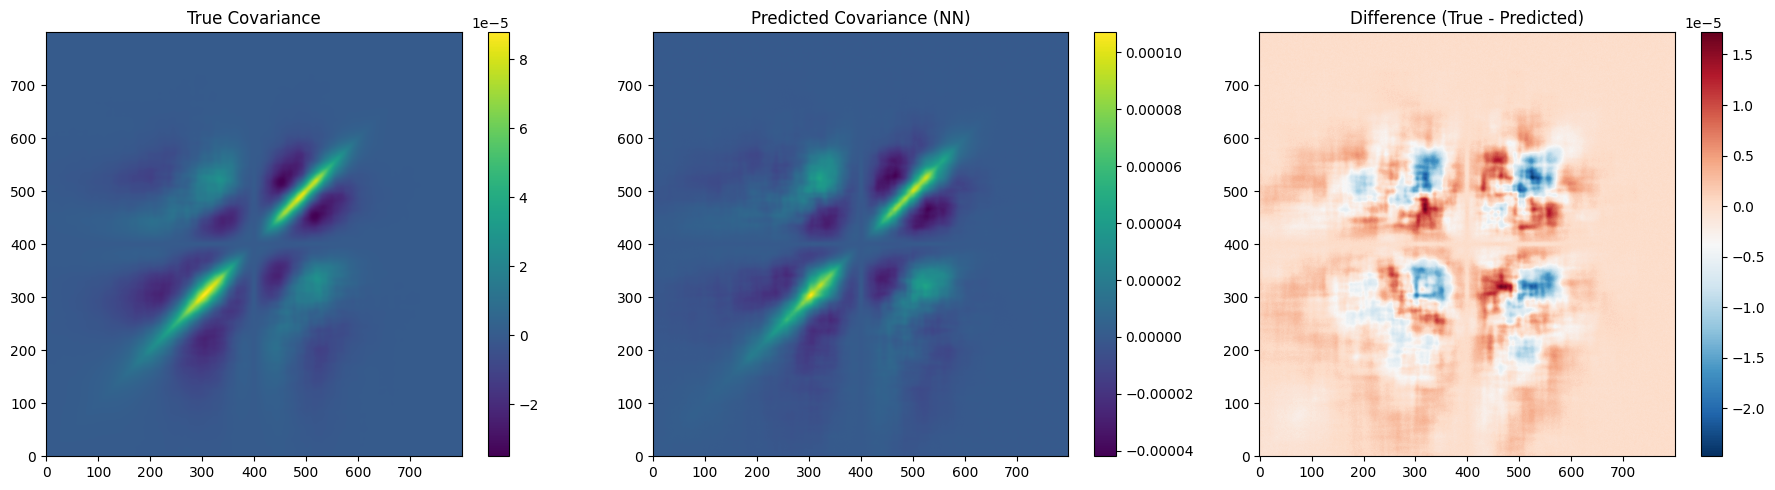

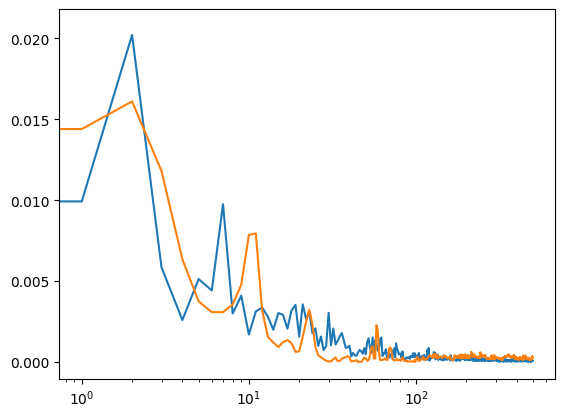

In [25]:
# --- 1. Fiducial cosmological parameters ---
Om_fid = 0.2905
sig8_fid = 0.8364
h_fid = 0.6898
w_fid = -1.0
cosmo_fid = np.array([Om_fid, sig8_fid, h_fid, w_fid])

# --- 2. Scale using your previously fitted scaler ---
cosmo_fid_scaled = scaler_X.transform(cosmo_fid.reshape(1, -1))

# --- 3. Predict vectorized covariance using your neural net ---
vec_pred = model.predict(cosmo_fid_scaled)[0]   # shape (N_vec,)

# --- 4. Reconstruct full symmetric covariance matrix ---
def reconstruct_cov(vec):
    n = int((-1 + np.sqrt(1 + 8 * len(vec))) // 2)
    C = np.zeros((n, n))
    idx = np.triu_indices(n)
    C[idx] = vec
    C[(idx[1], idx[0])] = vec
    return 0.5 * (C + C.T)

pred_cov_fid = reconstruct_cov(vec_pred)

# --- 5. Load true covariance from simulation ---
true_cov_fid = np.load("/feynman/work/dap/lcs/vt272285/inference/extrabins/cov_matrix_full_theta15.0_bin5.npy")

# --- 6. Visualize ---
plt.figure(figsize=(18, 5))
plt.subplot(1, 3, 1)
plt.title("True Covariance")
plt.imshow(true_cov_fid, cmap='viridis', aspect='auto', origin='lower')
plt.colorbar()

plt.subplot(1, 3, 2)
plt.title("Predicted Covariance (NN)")
plt.imshow(pred_cov_fid, cmap='viridis', aspect='auto', origin='lower')
plt.colorbar()

plt.subplot(1, 3, 3)
plt.title("Difference (True - Predicted)")
plt.imshow(true_cov_fid - pred_cov_fid, cmap='RdBu_r', aspect='auto', origin='lower')
plt.colorbar()

plt.tight_layout()
plt.show()
plt.plot(history.history['loss'], label='Train loss')
plt.plot(history.history['val_loss'], label='Val loss')
plt.xscale('log')
